In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import os
import glob
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version and GPU
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2025-12-18 05:51:23.224229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766037083.449597      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766037083.516689      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import os, zipfile

# Define paths
zip_path = '/kaggle/input/gait-major-dataset/WBDSascii'   # <-- this is a DIR, not .zip
info_path = '/kaggle/input/gait-major-dataset/WBDSinfo.xlsx'
extract_path = '/kaggle/working/WBDS_data/'

# If WBDSascii is already a folder → just copy its contents
print("Copying ASCII data (no extraction needed)...")

os.makedirs(extract_path, exist_ok=True)

# Copy all files from WBDSascii to working directory
for root, dirs, files in os.walk(zip_path):
    for file in files:
        src = os.path.join(root, file)
        dst = os.path.join(extract_path, file)
        if not os.path.exists(dst):  # avoid overwriting
            with open(src, 'rb') as fsrc, open(dst, 'wb') as fdst:
                fdst.write(fsrc.read())

print("Copy complete!")

# List extracted files
all_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        all_files.append(os.path.join(root, file))

print(f"\nTotal files found: {len(all_files)}")
print("\nFirst 10 files:")
for f in all_files[:10]:
    print(os.path.basename(f))


Copying ASCII data (no extraction needed)...
Copy complete!

Total files found: 4896

First 10 files:
WBDS38walkO10Smkr.txt
WBDS06walkT07mkr.txt
WBDS23walkOCknt.txt
WBDS17walkO10Sgrf.txt
WBDS25walkOCknt.txt
WBDS18walkO05Smkr.txt
WBDS21walkO03Cmkr.txt
WBDS09walkO03Cgrf.txt
WBDS07walkT06grf.txt
WBDS20walkT07grf.txt


In [3]:
import re
import numpy as np
import pandas as pd

info_path = '/kaggle/input/gait-major-dataset/WBDSinfo.xlsx'

# Read the sheet that has FileName/GaitSpeed (yours is "TreadHands")
sheets = pd.read_excel(info_path, sheet_name=None)
sheet_name = 'TreadHands' if 'TreadHands' in sheets else list(sheets.keys())[0]
info = sheets[sheet_name].copy()

# --- normalize names we need ---
info = info.rename(columns={
    'Subject':'Subject',
    'FileName':'FileName',
    'Age':'Age',
    'Gender':'Gender',
    'Height':'Height_cm',
    'Mass':'Mass_kg',
    'LegLength':'LegLength',        # looks like meters already (e.g., 0.89)
})

# Find the single gait-speed column robustly (handles 'GaitSpeed(m/s)')
gait_cols = [c for c in info.columns if 'gaitspeed' in str(c).lower()]
assert len(gait_cols)>=1, "Couldn't find a GaitSpeed column in WBDSinfo.xlsx"
gait_col = gait_cols[0]

# Keep **walking treadmill** trials with numeric speed
info[gait_col] = pd.to_numeric(info[gait_col], errors='coerce')     # '--' -> NaN
info = info[ info['FileName'].astype(str).str.contains(r'walkT\d+', case=False, regex=True) ]
info = info.dropna(subset=[gait_col]).reset_index(drop=True)

# Derive SpeedIndex: T01..T08 -> 1..8
info['SpeedIndex'] = info['FileName'].str.extract(r'[Tt]\s*0?(\d+)', expand=False).astype(int)

# Demographics / units
info['Gender']    = info['Gender'].astype(str).str.strip().str[0].str.upper().map({'M':0,'F':1}).astype(int)
info['Height_m']  = pd.to_numeric(info['Height_cm'], errors='coerce')/100.0
ll = pd.to_numeric(info['LegLength'], errors='coerce')
info['LegLength_m'] = ll/100.0 if ll.median()>3 else ll  # if cm, convert; else already meters

# Final schema used downstream
info = info[['Subject','FileName','Age','Gender','Height_m','Mass_kg','LegLength_m',gait_col,'SpeedIndex']]
info = info.rename(columns={gait_col:'GaitSpeed'})

print("Rows (treadmill trials with numeric speed):", len(info))
info.head(8)


Rows (treadmill trials with numeric speed): 984


,Subject,FileName,Age,Gender,Height_m,Mass_kg,LegLength_m,GaitSpeed,SpeedIndex
0,1,WBDS01walkT01.c3d,25,0,1.725,74.3,0.89,0.49,1
1,1,WBDS01walkT02.c3d,25,0,1.725,74.3,0.89,0.67,2
2,1,WBDS01walkT03.c3d,25,0,1.725,74.3,0.89,0.85,3
3,1,WBDS01walkT04.c3d,25,0,1.725,74.3,0.89,1.03,4
4,1,WBDS01walkT05.c3d,25,0,1.725,74.3,0.89,1.21,5
5,1,WBDS01walkT06.c3d,25,0,1.725,74.3,0.89,1.40,6
6,1,WBDS01walkT07.c3d,25,0,1.725,74.3,0.89,1.58,7
7,1,WBDS01walkT08.c3d,25,0,1.725,74.3,0.89,1.76,8


In [4]:
import glob, os
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import interpolate

extract_path = '/kaggle/working/WBDS_data/'

# Find ANG text files (case-insensitive): e.g., WBDS01walkT01ang.txt
patterns = [
    str(Path(extract_path) / "**/*ang.txt"),
    str(Path(extract_path) / "**/*ANG.TXT"),
    str(Path(extract_path) / "**/*_ang.txt"),
]
ang_txt_files = []
for p in patterns:
    ang_txt_files.extend(glob.glob(p, recursive=True))
ang_txt_files = sorted(set(ang_txt_files))

print("ANG .txt files found:", len(ang_txt_files))
print(ang_txt_files[:8])

def try_read_ang_txt(path):
    """
    Parse WBDS ANG .txt (whitespace- or comma-delimited).
    Returns 101-point dict: {'hip','knee','ankle'} in degrees.
    We search columns by flexible name matching.
    """
    # Many files are whitespace-delimited, sometimes commas; also sometimes first row is headers.
    df = pd.read_csv(path, sep=r'\s+|,', engine='python', comment='#')
    cols_lower = [c.lower() for c in df.columns]

    # Possible header aliases (seen across WBDS-like exports)
    candidates = [
        # Left leg
        {'hip':  ['lhip', 'lhipang', 'lhipangles', 'lhipflexion', 'lhf'],
         'knee': ['lknee','lkneeang','lkneeangles','lkneeflexion','lkf'],
         'ankle':['lankle','lankleang','lankleangles','lankleflexion','laf']},
        # Right leg
        {'hip':  ['rhip', 'rhipang', 'rhipangles', 'rhipflexion'],
         'knee': ['rknee','rkneeang','rkneeangles','rkneeflexion'],
         'ankle':['rankle','rankleang','rankleangles','rankleflexion']},
        # Generic
        {'hip':['hip','hipang','hipflexion'], 'knee':['knee','kneeang','kneeflexion'], 'ankle':['ankle','ankleang','ankleflexion']},
    ]

    def pick(colnames):
        # exact name
        for c in colnames:
            if c in cols_lower:
                return df.iloc[:, cols_lower.index(c)].to_numpy()
        # substring contains
        for c in colnames:
            for i, name in enumerate(cols_lower):
                if c in name:
                    return df.iloc[:, i].to_numpy()
        return None

    hip=knee=ankle=None
    for m in candidates:
        hip  = hip  or pick([s.lower() for s in m['hip']])
        knee = knee or pick([s.lower() for s in m['knee']])
        ankle= ankle or pick([s.lower() for s in m['ankle']])
        if hip is not None and knee is not None and ankle is not None:
            break

    if hip is None or knee is None or ankle is None:
        raise ValueError(f"Could not locate hip/knee/ankle in {os.path.basename(path)}; headers={list(df.columns)}")

    def to_101(arr):
        arr = np.asarray(arr, dtype=np.float32).reshape(-1)
        if arr.size == 101:
            return arr
        x = np.linspace(0,1,arr.size)
        f = interpolate.interp1d(x, arr, kind='cubic')
        return f(np.linspace(0,1,101)).astype(np.float32)

    return {'hip':to_101(hip), 'knee':to_101(knee), 'ankle':to_101(ankle)}


ANG .txt files found: 454
['/kaggle/working/WBDS_data/WBDS01walkOCang.txt', '/kaggle/working/WBDS_data/WBDS01walkOFang.txt', '/kaggle/working/WBDS_data/WBDS01walkOSang.txt', '/kaggle/working/WBDS_data/WBDS01walkT01ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT02ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT03ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT04ang.txt', '/kaggle/working/WBDS_data/WBDS01walkT05ang.txt']


In [5]:
import os, re, numpy as np, pandas as pd

def token_from_c3d(fn):
    # "WBDS01walkT01.c3d" -> "WBDS01walkT01"
    return os.path.splitext(os.path.basename(fn))[0]

# Prefer files that explicitly end with 'ang.txt' and contain the trial token
def find_matching_ang_txt(token):
    t = token.lower()
    # typical exact: WBDS01walkT01ang.txt
    exact = [f for f in ang_txt_files if t + 'ang.txt' == os.path.basename(f).lower()]
    if exact:
        return exact[0]
    # fallback: any file that contains token AND 'ang'
    fallback = [f for f in ang_txt_files if (t in os.path.basename(f).lower()) and ('ang' in os.path.basename(f).lower())]
    return fallback[0] if fallback else None

rows, missing = [], 0

for _, r in info.iterrows():
    tok = token_from_c3d(r['FileName'])
    fpath = find_matching_ang_txt(tok)
    if fpath is None:
        missing += 1
        # print("No ANG for", tok)
        continue

    series = try_read_ang_txt(fpath)
    base = dict(
        Age=float(r['Age']),
        Height_m=float(r['Height_m']),
        Gender=int(r['Gender']),
        Mass_kg=float(r['Mass_kg']),
        GaitSpeed=float(r['GaitSpeed']),
        LegLength_m=float(r['LegLength_m']),
        Subject=int(r['Subject']),
        SpeedIndex=int(r['SpeedIndex']),
        FileToken=tok
    )
    for (jname, jid) in [('hip',0),('knee',1),('ankle',2)]:
        rows.append({**base, 'JointNumber':jid, 'y':series[jname].astype(np.float32)})

df = pd.DataFrame(rows)
print(f"Samples built from ANG .txt: {len(df)}  |  Trials without ANG: {missing}")
df.head(3)


Samples built from ANG .txt: 984  |  Trials without ANG: 656


,Age,Height_m,Gender,Mass_kg,GaitSpeed,LegLength_m,Subject,SpeedIndex,FileToken,JointNumber,y
0,25.0,1.725,0,74.3,0.49,0.89,1,1,WBDS01walkT01,0,"[2.63645, 2.48031, 2.45842, 2.56017, 2.75832, ..."
1,25.0,1.725,0,74.3,0.49,0.89,1,1,WBDS01walkT01,1,"[1.05117, 1.18253, 1.27917, 1.4841, 1.8522, 2...."
2,25.0,1.725,0,74.3,0.49,0.89,1,1,WBDS01walkT01,2,"[-3.54135, -3.31268, -3.09913, -3.07285, -3.39..."


In [6]:
## this is the train and test split code in this cell

import numpy as np
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

# choose exactly one speed per subject for test
choice = {}
for s in sorted(df['Subject'].unique()):
    speeds = sorted(df.loc[df['Subject']==s, 'SpeedIndex'].unique())
    choice[s] = int(rng.choice(speeds))

is_test = df.apply(lambda r: r['SpeedIndex']==choice[r['Subject']], axis=1)
train_df = df.loc[~is_test].reset_index(drop=True)
test_df  = df.loc[ is_test].reset_index(drop=True)

print("Subjects:", df['Subject'].nunique(),
      "| Train samples:", len(train_df),
      "| Test samples:", len(test_df))

feat_cols = ['Age','Height_m','Gender','Mass_kg','GaitSpeed','LegLength_m','JointNumber']
cont_cols = ['Age','Height_m','Mass_kg','GaitSpeed','LegLength_m']

scaler = StandardScaler().fit(train_df[cont_cols])

def make_XY(frame):
    f = frame.copy()
    f[cont_cols] = scaler.transform(f[cont_cols])
    X2d = f[feat_cols].to_numpy(np.float32)         # (N,7)
    X3d = np.repeat(X2d[:, None, :], 101, axis=1)   # (N,101,7)
    Y3d = np.stack(f['y'].to_list(), axis=0).astype(np.float32)  # (N,101)
    Y3d = Y3d[:, :, None]                           # (N,101,1)
    return X3d, Y3d

train_X, train_Y = make_XY(train_df)
test_X,  test_Y  = make_XY(test_df)

train_X.shape, train_Y.shape, test_X.shape, test_Y.shape


Subjects: 42 | Train samples: 858 | Test samples: 126


((858, 101, 7), (858, 101, 1), (126, 101, 7), (126, 101, 1))

In [7]:
## from here beginning the testing of the same

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

time_steps = 101
n_feats = len(feat_cols)

def build_lstm_cnn():
    inp = keras.Input(shape=(time_steps, n_feats))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)  # 101 values
    out = layers.Reshape((time_steps, 1))(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse')
    return model

model = build_lstm_cnn()
model.summary()


I0000 00:00:1766037140.140195      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766037140.140846      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 101, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 101, 128)       │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 101, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 101, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │        25,957 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 101, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,749 (3.58 MB)

 Trainable params: 939,749 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
]

history = model.fit(
    train_X, train_Y,
    validation_split=0.1,
    epochs= 350,
    batch_size=64,
    verbose=1,
    shuffle=True
)



Epoch 1/350


I0000 00:00:1766037144.383714      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 24.8840 - val_loss: 18.8170
Epoch 2/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 16.4952 - val_loss: 12.6189
Epoch 3/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 16.7256 - val_loss: 13.8448
Epoch 4/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 14.4821 - val_loss: 12.9048
Epoch 5/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.9588 - val_loss: 13.4096
Epoch 6/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.2701 - val_loss: 12.3067
Epoch 7/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.9083 - val_loss: 11.7793
Epoch 8/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.8809 - val_loss: 12.6331
Epoch 9/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.2674 - val_loss: 13.1199
Epoch 10/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 12.7657 - val_loss: 11.5378
Epoch 11/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 12.0928 - val_loss: 14.2811
Epoch 12/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s

In [9]:
import numpy as np, math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model.predict(test_X, verbose=0).squeeze(-1)  # (N,101)
true = test_Y.squeeze(-1)

def pearsonr_rows(a,b):
    a = a - a.mean(axis=1, keepdims=True)
    b = b - b.mean(axis=1, keepdims=True)
    num = np.sum(a*b, axis=1)
    den = np.sqrt(np.sum(a*a,axis=1) * np.sum(b*b,axis=1)) + 1e-8
    return num/den

overall_mae  = mean_absolute_error(true.ravel(), pred.ravel())
overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
overall_r2   = r2_score(true.ravel(), pred.ravel())
overall_r    = pearsonr_rows(true, pred).mean()
print(f"OVERALL  MAE={overall_mae:.3f}  RMSE={overall_rmse:.3f}  R2={overall_r2:.3f}  r={overall_r:.3f}")

names = {0:'Hip',1:'Knee',2:'Ankle'}
for j in [0,1,2]:
    m = (test_df['JointNumber']==j).to_numpy()
    yj, pj = true[m], pred[m]
    mae  = mean_absolute_error(yj.ravel(), pj.ravel())
    rmse = math.sqrt(mean_squared_error(yj.ravel(), pj.ravel()))
    r2   = r2_score(yj.ravel(), pj.ravel())
    r    = pearsonr_rows(yj, pj).mean()
    print(f"{names[j]:5s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}  r={r:.3f}")


OVERALL  MAE=1.138  RMSE=1.905  R2=0.841  r=0.940
Hip    MAE=1.060  RMSE=1.728  R2=0.857  r=0.973
Knee   MAE=0.914  RMSE=1.405  R2=0.908  r=0.909
Ankle  MAE=1.439  RMSE=2.435  R2=0.771  r=0.939


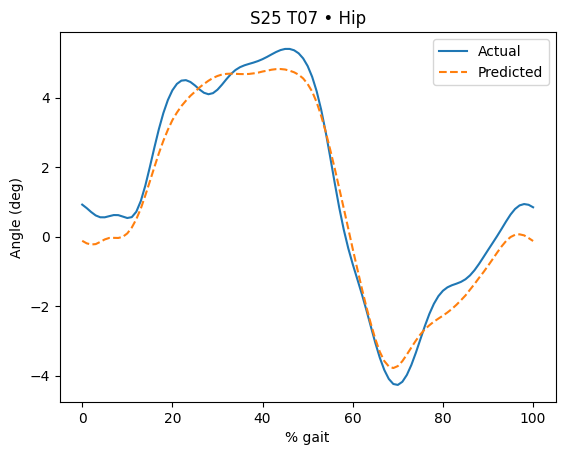

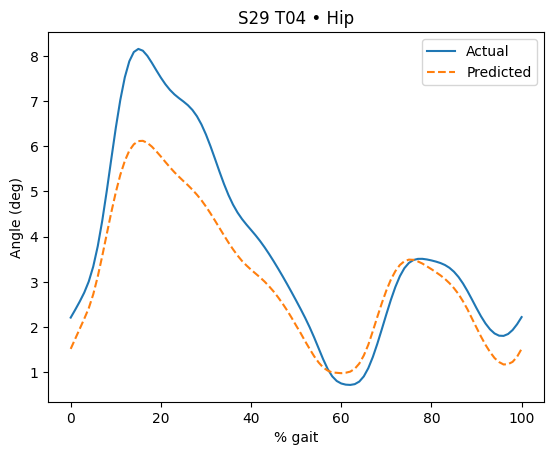

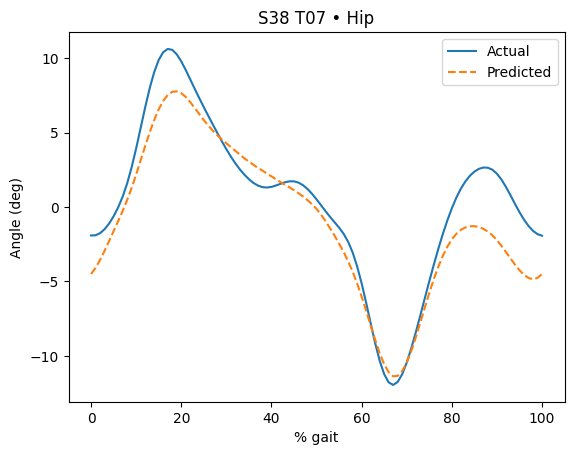

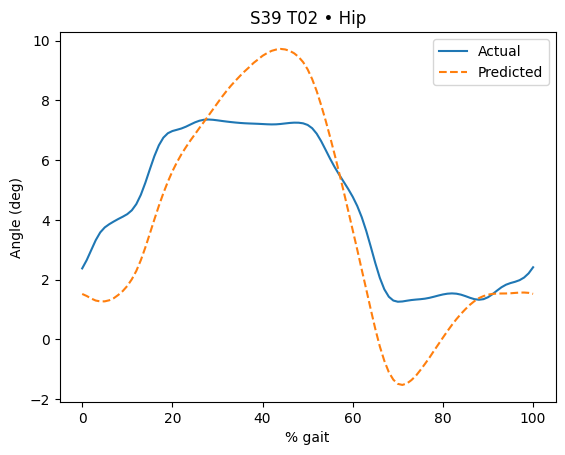

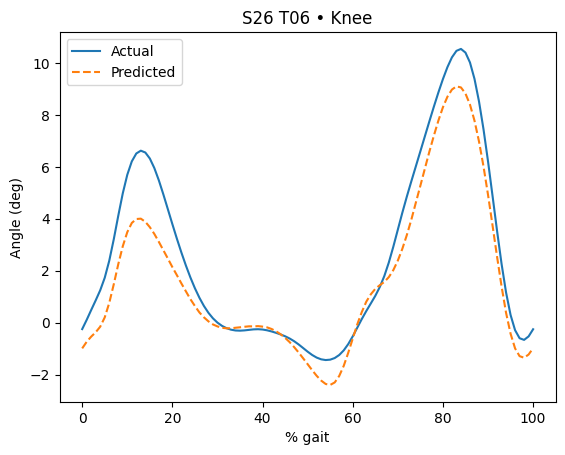

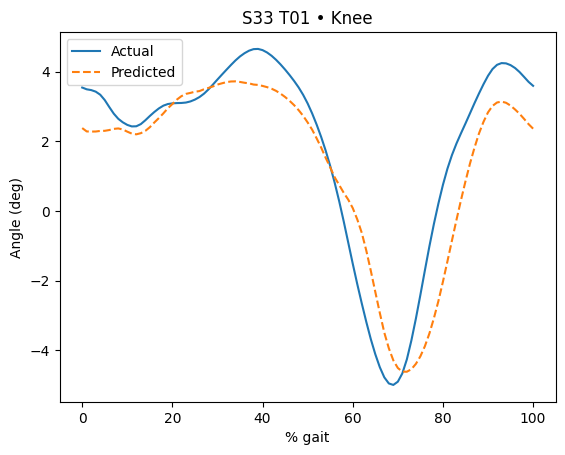

In [10]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)
k = min(6, len(test_df))
for idx in rng.choice(len(test_df), size=k, replace=False):
    plt.figure()
    plt.plot(true[idx], label='Actual')
    plt.plot(pred[idx], label='Predicted', linestyle='--')
    meta = test_df.iloc[idx]
    jt = {0:'Hip',1:'Knee',2:'Ankle'}[int(meta.JointNumber)]
    plt.title(f"S{int(meta.Subject)} T{int(meta.SpeedIndex):02d} • {jt}")
    plt.xlabel('% gait'); plt.ylabel('Angle (deg)'); plt.legend(); plt.show()


In [11]:
##from here i am working for the novelty part of the project 

import numpy as np, math, pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras

def make_XY_from_df(frame, scaler, feat_cols, cont_cols):
    f = frame.copy()
    f[cont_cols] = scaler.transform(f[cont_cols])
    X2d = f[feat_cols].to_numpy(np.float32)
    X3d = np.repeat(X2d[:, None, :], 101, axis=1)
    Y3d = np.stack(f['y'].to_list(), axis=0).astype(np.float32)
    Y3d = Y3d[:, :, None]
    return X3d, Y3d

def train_and_eval(build_fn, name, train_df, test_df, scaler, feat_cols, cont_cols, epochs=350, batch_size=64):
    Xtr, Ytr = make_XY_from_df(train_df, scaler, feat_cols, cont_cols)
    Xte, Yte = make_XY_from_df(test_df,  scaler, feat_cols, cont_cols)
    model = build_fn()
    cbs = [
        keras.callbacks.ModelCheckpoint(f'/kaggle/working/models/best_{name}.keras',
                                        monitor='val_loss', save_best_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5, verbose=0),
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=0),
    ]
    hist = model.fit(Xtr, Ytr, validation_split=0.1, epochs=epochs, batch_size=batch_size,
                     callbacks=cbs, verbose=0, shuffle=True)

    pred = model.predict(Xte, verbose=0).squeeze(-1)
    true = Yte.squeeze(-1)

    def r_rowwise(a,b):
        a = a - a.mean(axis=1, keepdims=True)
        b = b - b.mean(axis=1, keepdims=True)
        num = np.sum(a*b, axis=1)
        den = np.sqrt(np.sum(a*a,axis=1) * np.sum(b*b,axis=1)) + 1e-8
        return (num/den)

    overall_mae  = mean_absolute_error(true.ravel(), pred.ravel())
    overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
    overall_r2   = r2_score(true.ravel(), pred.ravel())
    overall_r    = r_rowwise(true, pred).mean()

    jt_names = {0:'Hip',1:'Knee',2:'Ankle'}
    rows=[]
    for j in [0,1,2]:
        m = (test_df['JointNumber']==j).to_numpy()
        yj, pj = true[m], pred[m]
        rows.append({
            "Model": name, "Joint": jt_names[j],
            "MAE": mean_absolute_error(yj.ravel(), pj.ravel()),
            "RMSE": math.sqrt(mean_squared_error(yj.ravel(), pj.ravel())),
            "R2": r2_score(yj.ravel(), pj.ravel()),
            "r": r_rowwise(yj, pj).mean()
        })
    rows.append({"Model": name, "Joint": "Overall",
                 "MAE": overall_mae, "RMSE": overall_rmse, "R2": overall_r2, "r": overall_r})
    return model, pd.DataFrame(rows)


In [12]:
from tensorflow import keras
from tensorflow.keras import layers

time_steps = 101
n_feats = len(feat_cols)

# A) Baseline (for re-run or fair comparison)
def build_lstm_cnn():
    inp = keras.Input(shape=(time_steps, n_feats))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)
    out = layers.Reshape((time_steps,1))(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
    return m

# B) Bi-LSTM + CNN (novelty 1)
def build_bilstm_cnn():
    inp = keras.Input(shape=(time_steps, n_feats))
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))(inp)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)
    out = layers.Reshape((time_steps,1))(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(0.005), loss='mse')  # slightly lower LR helps Bi-LSTM
    return m

# C) Lightweight Transformer Encoder (novelty 2)
def build_transformer():
    d_model   = 64          # projection size
    n_heads   = 4
    key_dim   = d_model // n_heads

    inp = keras.Input(shape=(time_steps, n_feats))

    # Project inputs to d_model
    x = layers.Dense(d_model)(inp)   # (B, T, d_model)

    # Learnable positional embeddings: (1, T, d_model) broadcast over batch
    pos_emb = layers.Embedding(input_dim=time_steps, output_dim=d_model)
    pos_idx = tf.range(time_steps)[tf.newaxis, :]                  # (1, T)
    pos     = pos_emb(pos_idx)                                     # (1, T, d_model)
    x = layers.Add()([x, pos])                                     # (B, T, d_model)

    # 2 Transformer encoder blocks
    for _ in range(2):
        attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=key_dim, dropout=0.1)(x, x)
        x = layers.LayerNormalization()(x + attn)

        ff = layers.Dense(128, activation='relu')(x)
        ff = layers.Dense(d_model)(ff)
        x = layers.LayerNormalization()(x + ff)

    # light CNN head to smooth sequence
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(time_steps, activation='linear')(x)           # 101 outputs
    out = layers.Reshape((time_steps, 1))(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model


In [13]:
from pathlib import Path
Path('/kaggle/working/models').mkdir(exist_ok=True, parents=True)

results = []

_, df_base = train_and_eval(build_lstm_cnn,   "LSTM-CNN",  train_df, test_df, scaler, feat_cols, cont_cols
, epochs=200)
_, df_bi   = train_and_eval(build_bilstm_cnn, "BiLSTM-CNN",train_df, test_df, scaler, feat_cols, cont_cols
, epochs=200)
_, df_tr   = train_and_eval(build_transformer,"Transformer",train_df, test_df, scaler, feat_cols, cont_cols
, epochs=200)

cmp = pd.concat([df_base, df_bi, df_tr], ignore_index=True)
cmp


I0000 00:00:1766037500.010090      62 service.cc:148] XLA service 0x798bb5227210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766037500.012584      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766037500.012611      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766037505.534361      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


,Model,Joint,MAE,RMSE,R2,r
0,LSTM-CNN,Hip,2.311926,2.878284,0.604219,0.891483
1,LSTM-CNN,Knee,3.137853,4.048651,0.233492,0.641933
2,LSTM-CNN,Ankle,3.278585,4.098911,0.349785,0.784311
3,LSTM-CNN,Overall,2.909455,3.718295,0.393744,0.772576
4,BiLSTM-CNN,Hip,2.222674,2.792868,0.627361,0.910463
5,BiLSTM-CNN,Knee,2.749511,3.716689,0.354036,0.663177
6,BiLSTM-CNN,Ankle,2.907207,3.759998,0.452864,0.844884
7,BiLSTM-CNN,Overall,2.626464,3.452123,0.477434,0.806175
8,Transformer,Hip,2.220192,2.785406,0.629349,0.895410
9,Transformer,Knee,3.011486,4.066167,0.226845,0.485566


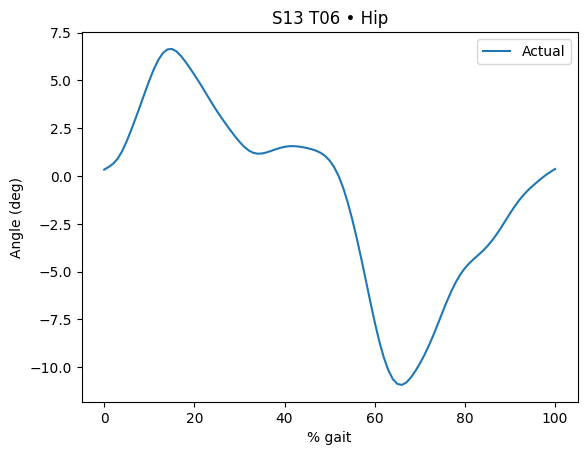

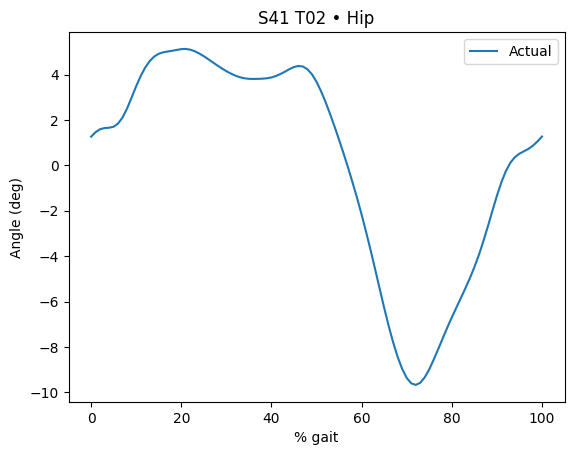

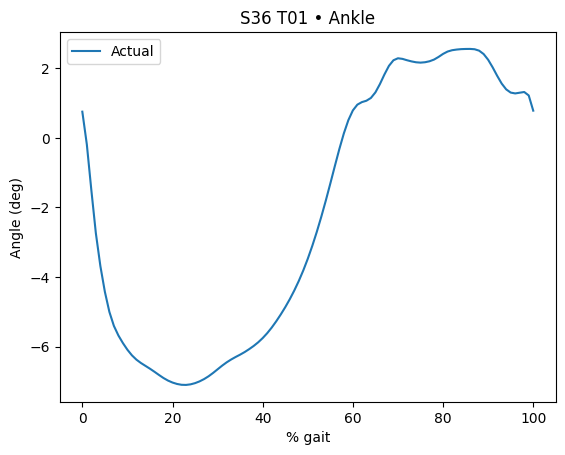

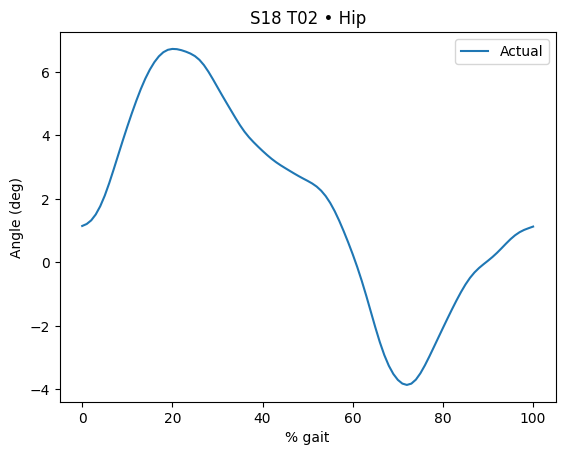

In [14]:
import matplotlib.pyplot as plt
rng = np.random.default_rng(9)
idxs = rng.choice(len(test_df), size=min(4, len(test_df)), replace=False)

def plot_model(model_builder, title):
    Xte, Yte = make_XY_from_df(test_df, scaler, feat_cols, meta['cont_cols'])
    pred = model_builder().predict(Xte, verbose=0).squeeze(-1)  # only to show structure if not trained here
    # Replace the line above with loading the saved best model for that builder if desired.

for idx in idxs:
    plt.figure()
    plt.plot(test_Y[idx,:,0], label='Actual')
    # If you saved each best model, you can load and predict from them similarly to the reload cell.
    plt.title(f"S{int(test_df.iloc[idx].Subject)} T{int(test_df.iloc[idx].SpeedIndex):02d} • "
              f"{['Hip','Knee','Ankle'][int(test_df.iloc[idx].JointNumber)]}")
    plt.xlabel('% gait'); plt.ylabel('Angle (deg)')
    plt.legend(); plt.show()


Trials with all three joints in test set: 42


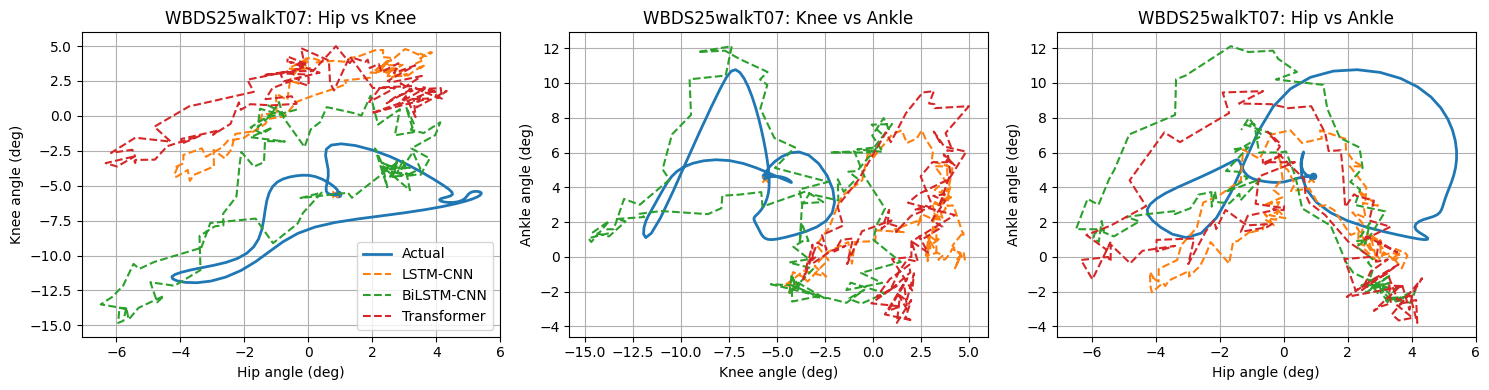

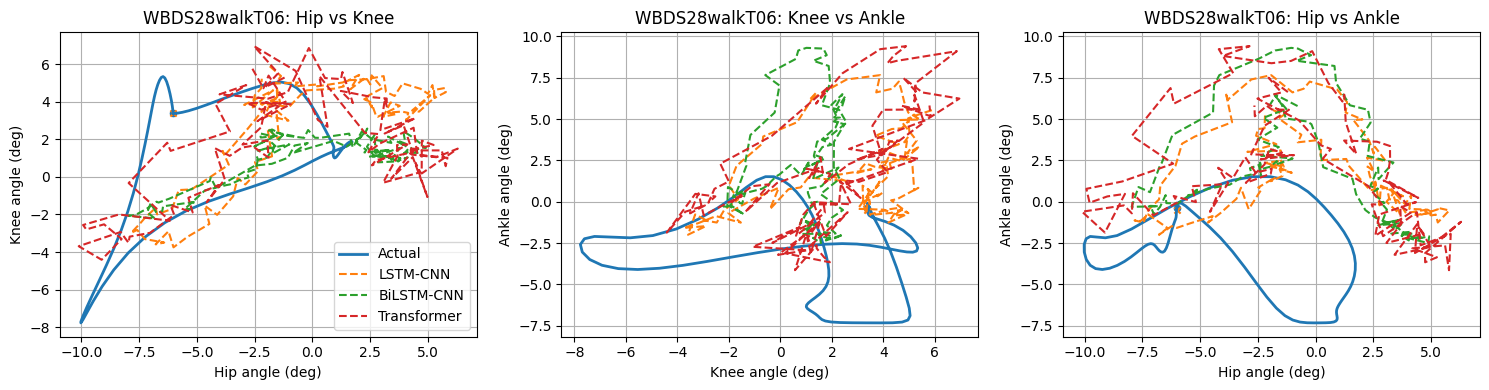

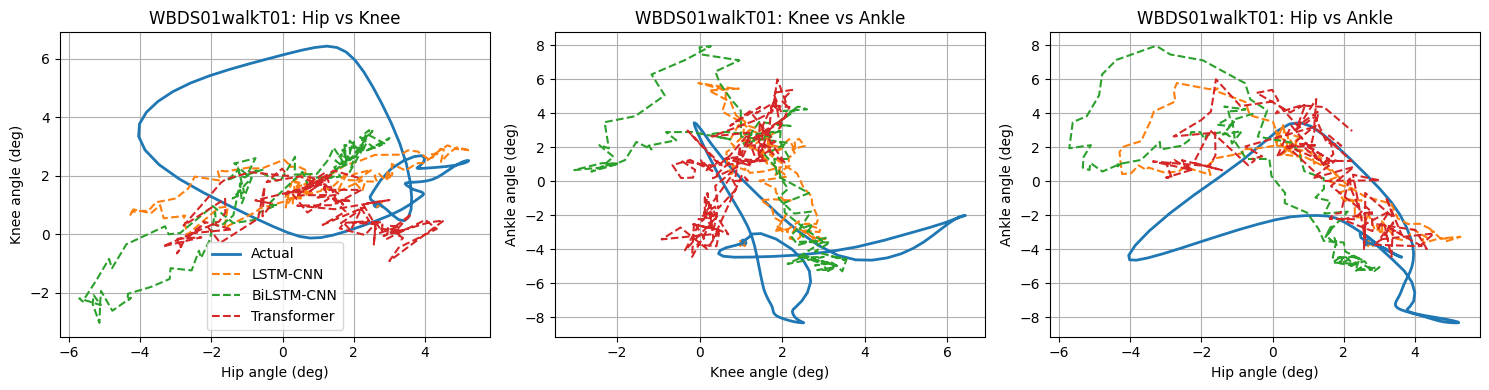

In [15]:
# === Cyclogram plots for multiple models (Actual vs Pred) ===
# Requirements in memory: test_df, scaler, feat_cols, meta['cont_cols'], make_XY_from_df()
# Optional saved models (if you trained with the comparison code): 
#   /kaggle/working/models/best_LSTM-CNN.keras
#   /kaggle/working/models/best_BiLSTM-CNN.keras
#   /kaggle/working/models/best_Transformer.keras

import os, numpy as np, matplotlib.pyplot as plt
from tensorflow import keras

# ------------- helpers -------------
def load_or_use(name, fallback_model=None):
    path = f"/kaggle/working/models/best_{name}.keras"
    if os.path.exists(path):
        return keras.models.load_model(path)
    return fallback_model  # can be None

def predict_all(model):
    """Predict on the test set and return (N,101) predictions aligned to test_df rows."""
    Xte, Yte = make_XY_from_df(test_df, scaler, feat_cols, cont_cols)
    pred = model.predict(Xte, verbose=0).squeeze(-1)  # (N,101)
    return pred

# Load models (or use in-memory variables named model_bilstm, model_tr, etc. if you have them)
mdl_lstm = load_or_use("LSTM-CNN",     fallback_model=None)
mdl_bi   = load_or_use("BiLSTM-CNN",   fallback_model=None)
mdl_tr   = load_or_use("Transformer",  fallback_model=None)

# Gather predictions
preds = {}
if mdl_lstm is not None: preds["LSTM-CNN"]    = predict_all(mdl_lstm)
if mdl_bi   is not None: preds["BiLSTM-CNN"]  = predict_all(mdl_bi)
if mdl_tr   is not None: preds["Transformer"] = predict_all(mdl_tr)

# Ground truth (aligned with test_df)
_, Yte = make_XY_from_df(test_df, scaler, feat_cols, cont_cols)
true = Yte.squeeze(-1)  # (N,101)

# Map joints and group rows by trial token so we can pair joints from the SAME trial
jt_name = {0:"Hip", 1:"Knee", 2:"Ankle"}
by_token = {}
for i, r in test_df.reset_index().iterrows():
    tok = r["FileToken"]
    if tok not in by_token: by_token[tok] = {}
    by_token[tok][int(r["JointNumber"])] = i

# keep only tokens where we have all three joints
complete_tokens = [t for t, m in by_token.items() if all(k in m for k in (0,1,2))]
print(f"Trials with all three joints in test set: {len(complete_tokens)}")

# -------- cyclogram plotting function --------
def plot_cyclogram_for_token(token, pairs=(("Hip","Knee"), ("Knee","Ankle"), ("Hip","Ankle"))):
    idx_hip = by_token[token][0]
    idx_knee = by_token[token][1]
    idx_ankle = by_token[token][2]
    
    # Actual curves
    act = {"Hip": true[idx_hip], "Knee": true[idx_knee], "Ankle": true[idx_ankle]}
    # Preds per model
    preds_token = {}
    for name, P in preds.items():
        preds_token[name] = {
            "Hip":   P[idx_hip],
            "Knee":  P[idx_knee],
            "Ankle": P[idx_ankle],
        }

    ncols = len(pairs)
    plt.figure(figsize=(5*ncols, 4))
    for k, (a, b) in enumerate(pairs, start=1):
        plt.subplot(1, ncols, k)

        # Actual cyclogram
        plt.plot(act[a], act[b], label="Actual", linewidth=2)

        # Predicted cyclograms
        for name in preds_token:
            plt.plot(preds_token[name][a], preds_token[name][b], linestyle="--", label=name)

        # optional: mark start/end of gait cycle
        plt.scatter([act[a][0]],  [act[b][0]],  marker="o", s=20)
        plt.scatter([act[a][-1]],[act[b][-1]], marker="x", s=20)

        plt.xlabel(f"{a} angle (deg)")
        plt.ylabel(f"{b} angle (deg)")
        plt.title(f"{token}: {a} vs {b}")
        plt.grid(True)
        if k == 1:
            plt.legend()
    plt.tight_layout()
    plt.show()

# -------- choose a few random complete trials and plot --------
rng = np.random.default_rng(123)
show = min(3, len(complete_tokens))
for tok in rng.choice(complete_tokens, size=show, replace=False):
    plot_cyclogram_for_token(tok)


Models loaded: LSTM-CNN BiLSTM Transformer
Number of test samples: 126
Example indices (first 6) -> [0, 1, 2, 3, 4, 5]
Found complete token with 3 joints: WBDS01walkT01
Indices for that token (hip,knee,ankle): [0, 1, 2]


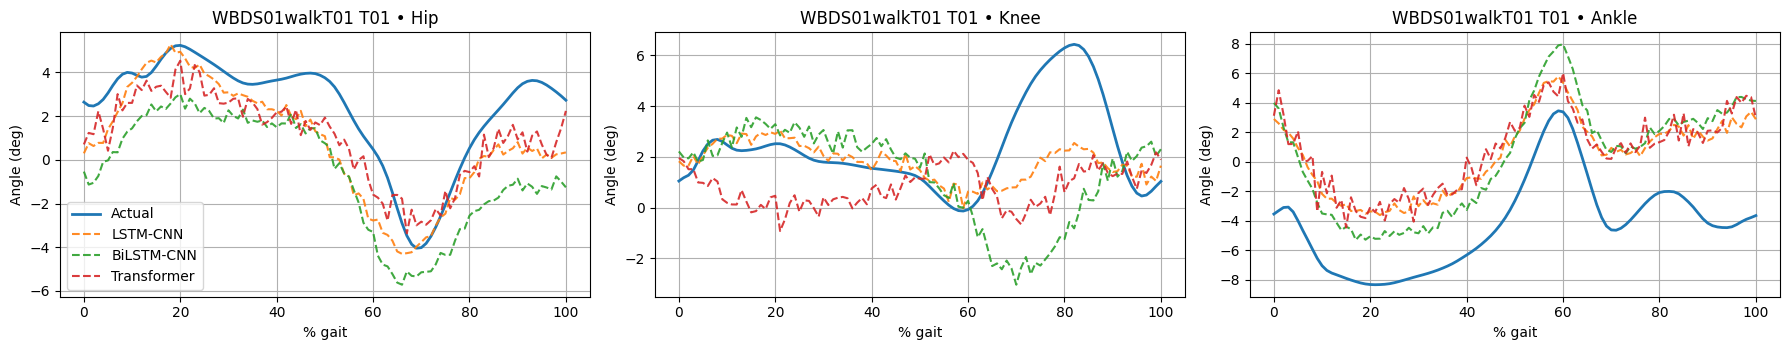

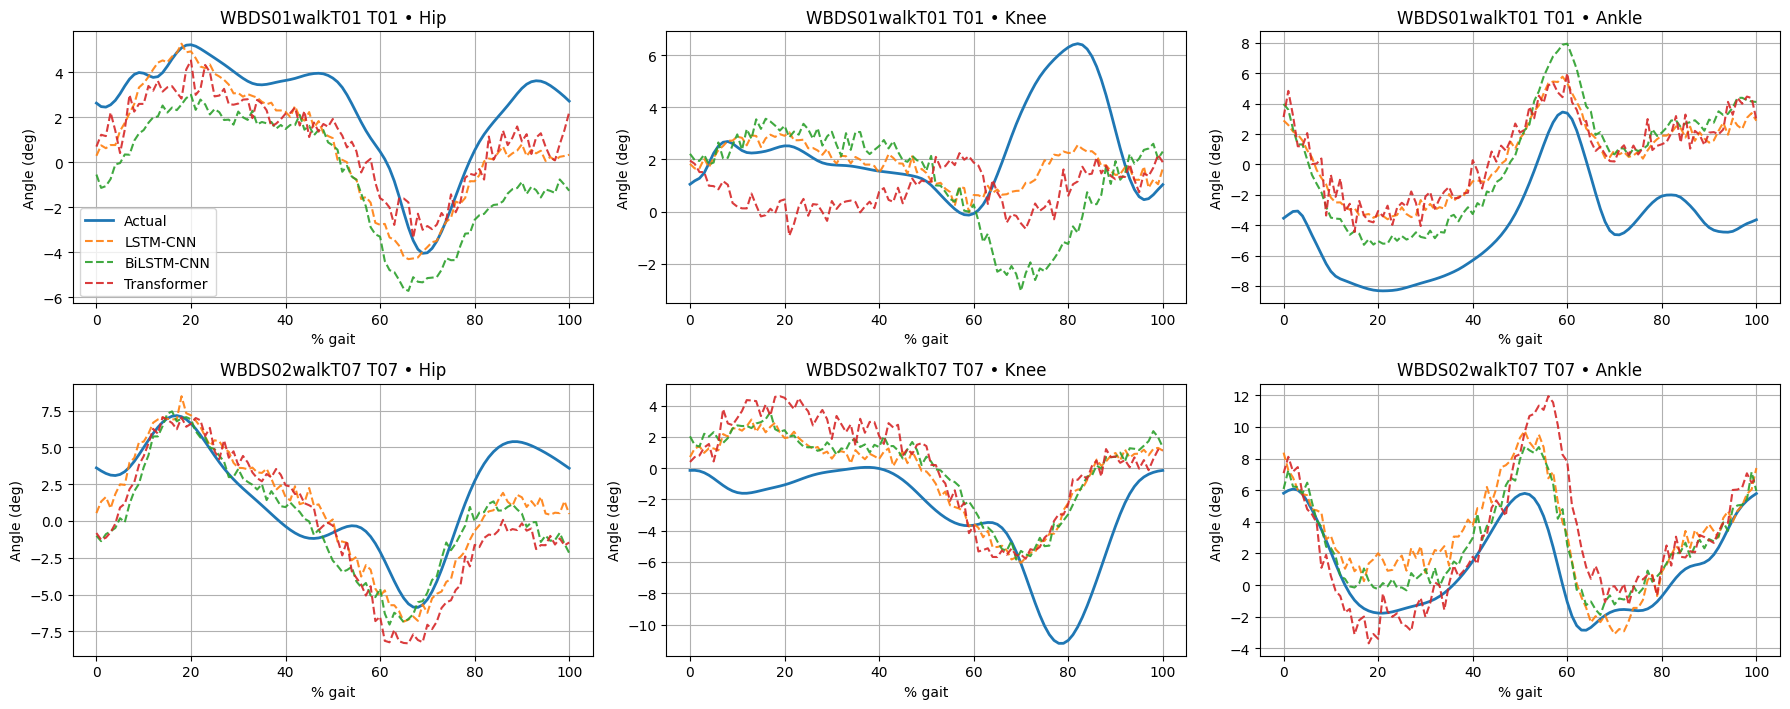

In [16]:
# Combined plot for all three models: LSTM-CNN, BiLSTM-CNN, Transformer
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# --------- Helper: safe load (avoid lambda deserialization) ----------
def safe_load_model(path, build_fn=None, weights_only_path=None):
    """
    Try to load full saved model without compiling (to avoid lambda deserialization).
    If that fails and weights_only_path is provided, build model with build_fn and load weights.
    """
    if os.path.exists(path):
        try:
            return keras.models.load_model(path, compile=False)
        except Exception as e:
            print(f"Warning: load_model compile=False failed for {path}: {e}")
            # fall through to weights-only option
    if build_fn is not None and weights_only_path is not None and os.path.exists(weights_only_path):
        print(f"Loading weights into model from {weights_only_path}")
        m = build_fn()
        m.load_weights(weights_only_path)
        return m
    # nothing found
    return None

# Paths (adjust if you saved elsewhere)
path_lstm = "/kaggle/working/models/best_LSTM-CNN.keras"
path_bi   = "/kaggle/working/models/best_BiLSTM-CNN.keras"
path_tr   = "/kaggle/working/models/best_Transformer.keras"

# Optionally you may have saved weights-only files named like:
w_lstm = "/kaggle/working/models/best_LSTM-CNN.weights.h5"
w_bi   = "/kaggle/working/models/best_BiLSTM-CNN.weights.h5"
w_tr   = "/kaggle/working/models/best_Transformer.weights.h5"

# Build functions (must be in scope; if not, import/redefine them)
# build_lstm_cnn, build_bilstm_cnn, build_transformer expected to exist

mdl_lstm = safe_load_model(path_lstm, build_fn=build_lstm_cnn, weights_only_path=w_lstm)
mdl_bi   = safe_load_model(path_bi,   build_fn=build_bilstm_cnn, weights_only_path=w_bi)
mdl_tr   = safe_load_model(path_tr,   build_fn=build_transformer,  weights_only_path=w_tr)

print("Models loaded:", 
      "LSTM-CNN" if mdl_lstm is not None else "(no LSTM)", 
      "BiLSTM"  if mdl_bi   is not None else "(no BiLSTM)",
      "Transformer" if mdl_tr is not None else "(no Transformer)")

# --------- Prepare predictions (on test set) ----------
# Ensure cont_cols exists in this session
if 'cont_cols' not in globals():
    cont_cols = ['Age','Height_m','Mass_kg','GaitSpeed','LegLength_m']

Xte, Yte = make_XY_from_df(test_df, scaler, feat_cols, cont_cols)  # uses your helper
true = Yte.squeeze(-1)  # (N, 101)

preds = {}
if mdl_lstm is not None:
    preds['LSTM-CNN'] = mdl_lstm.predict(Xte, verbose=0).squeeze(-1)
if mdl_bi is not None:
    preds['BiLSTM-CNN'] = mdl_bi.predict(Xte, verbose=0).squeeze(-1)
if mdl_tr is not None:
    preds['Transformer'] = mdl_tr.predict(Xte, verbose=0).squeeze(-1)

if not preds:
    raise RuntimeError("No models available to predict. Make sure you saved models or weights and build functions exist.")

# --------- Plotting function ----------
def plot_combined_indices(indices, joint_label_map={0:'Hip',1:'Knee',2:'Ankle'}):
    """
    indices: list of integer indices into test_df (rows). Each index corresponds to one joint sample.
    We expect each index to be one row in test_df; ensure you pick a row whose joint you want to plot.
    For clearer comparison, choose indices that correspond to the same joint across different trials, or choose
    complete triples (Hip/Knee/Ankle) and plot them separately.
    """
    n = len(indices)
    cols = 2 if n <= 2 else 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(6*cols, 3.6*rows))
    
    for i, idx in enumerate(indices):
        r = test_df.reset_index().iloc[idx]   # meta row
        jointnum = int(r['JointNumber'])
        jointname = joint_label_map.get(jointnum, f"Joint{jointnum}")
        
        ax = plt.subplot(rows, cols, i+1)
        # Actual
        ax.plot(true[idx], label='Actual', color='tab:blue', linewidth=2)
        # Each model
        styles = {'LSTM-CNN': ('tab:orange','--'), 'BiLSTM-CNN': ('tab:green','--'), 'Transformer':('tab:red','--')}
        for name, P in preds.items():
            if idx < P.shape[0]:
                color, ls = styles.get(name, ('k','--'))
                ax.plot(P[idx], label=name, color=color, linestyle=ls, alpha=0.9)
        ax.set_title(f"{r['FileToken']} T{int(r['SpeedIndex']):02d} • {jointname}", fontsize=12)
        ax.set_xlabel('% gait'); ax.set_ylabel('Angle (deg)')
        ax.grid(True)
        if i == 0:
            ax.legend()
    plt.tight_layout()
    plt.show()

# --------- How to select indices ---------
# Option A: pick a couple of representative indices manually (use test_df.head() to find interesting rows)
# Example: pick the first 6 rows of test_df (change as needed)
example_indices = list(range(min(6, len(test_df))))

# Option B: pick one complete trial (Hip/Knee/Ankle) and plot those 3 joints separately:
#   find a FileToken that has all three joints in test_df
by_token = {}
for i, r in test_df.reset_index().iterrows():
    tok = r['FileToken']
    by_token.setdefault(tok, []).append(i)
complete_tok = None
for tok, idxs in by_token.items():
    joints = sorted([int(test_df.reset_index().iloc[i]['JointNumber']) for i in idxs])
    if set([0,1,2]).issubset(set(joints)):
        complete_tok = tok
        complete_idxs = sorted(idxs, key=lambda j: int(test_df.reset_index().iloc[j]['JointNumber']))
        break

# Choose what to plot:
print("Number of test samples:", len(test_df))
print("Example indices (first 6) ->", example_indices)
if complete_tok:
    print("Found complete token with 3 joints:", complete_tok)
    print("Indices for that token (hip,knee,ankle):", complete_idxs)
    # Plot both: the complete trial joints and some other examples
    plot_combined_indices(complete_idxs)        # the triple for one trial
    plot_combined_indices(example_indices)      # first few samples
else:
    # No complete token found -> just plot examples
    plot_combined_indices(example_indices)


In [17]:
##saving the work
import os, json, pickle
from pathlib import Path

save_dir = Path('/kaggle/working/saved_gait_project')
save_dir.mkdir(parents=True, exist_ok=True)

# 1. Save baseline model
model.save(save_dir / 'lstm_cnn_baseline.keras')

# 2. Save scaler
with open(save_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save train/test file mapping
split_data = {
    "train": train_df[['FileToken', 'JointNumber']].to_dict(orient='records'),
    "test":  test_df[['FileToken', 'JointNumber']].to_dict(orient='records')
}
json.dump(split_data, open(save_dir / 'train_test_split.json', 'w'))

# 4. Save metadata
metadata = {
    "feature_columns": feat_cols,
    "continuous_columns": cont_cols,
    "time_steps": 101,
    "random_seed": 42
}
json.dump(metadata, open(save_dir / 'metadata.json', 'w'))

# 5. Save clean processed data
train_df.to_csv(save_dir / 'train_df.csv', index=False)
test_df.to_csv(save_dir / 'test_df.csv', index=False)

print(f"✅ All project files saved to: {save_dir}")


✅ All project files saved to: /kaggle/working/saved_gait_project


# Part 1: Comprehensive CNN-LSTM Model Implementation

This section performs the complete workflow using the CNN-LSTM model (CNN layers followed by LSTM), including training, evaluation, and detailed analysis.


In [18]:
# Comprehensive CNN-LSTM Model Implementation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from pathlib import Path
import os

# Ensure output directory exists
os.makedirs('/kaggle/working/models/cnn_lstm', exist_ok=True)

time_steps = 101
n_feats = len(feat_cols)

def build_cnn_lstm_model(conv1_filters=64, conv2_filters=64, kernel_size=2,
                         lstm_units=128, dense_units=256, learning_rate=0.01):
    """
    Build CNN-LSTM model architecture (CNN layers first, then LSTM)
    """
    inp = keras.Input(shape=(time_steps, n_feats))
    
    # Convolutional layers for feature extraction (applied first)
    x = layers.Conv1D(conv1_filters, kernel_size, activation='relu', padding='same')(inp)
    x = layers.Conv1D(conv2_filters, kernel_size, activation='relu', padding='same')(x)
    
    # Optional: Max pooling before LSTM
    # x = layers.MaxPooling1D(2)(x)  # Uncomment if you want pooling
    
    # LSTM layer to capture temporal dependencies (applied after CNN)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    
    # Flatten and fully connected layers
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    
    # Output layer: predict 101 time steps
    x = layers.Dense(time_steps, activation='linear')(x)
    out = layers.Reshape((time_steps, 1))(x)
    
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# Build the model
cnn_lstm_model = build_cnn_lstm_model()
print("CNN-LSTM Model Architecture:")
cnn_lstm_model.summary()


CNN-LSTM Model Architecture:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 101, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 101, 64)        │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 101, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 101, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     3,309,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 101)            │        25,957 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 101, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,443,813 (13.14 MB)

 Trainable params: 3,443,813 (13.14 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Prepare data for CNN-LSTM model
def prepare_data_for_model(train_df, test_df, scaler, feat_cols, cont_cols):
    """Prepare training and testing data in the format required by the model"""
    def make_XY(frame):
        f = frame.copy()
        f[cont_cols] = scaler.transform(f[cont_cols])
        X2d = f[feat_cols].to_numpy(np.float32)
        X3d = np.repeat(X2d[:, None, :], 101, axis=1)
        Y3d = np.stack(f['y'].to_list(), axis=0).astype(np.float32)
        Y3d = Y3d[:, :, None]
        return X3d, Y3d
    
    train_X, train_Y = make_XY(train_df)
    test_X, test_Y = make_XY(test_df)
    return train_X, train_Y, test_X, test_Y

# Prepare data
train_X_cnn_lstm, train_Y_cnn_lstm, test_X_cnn_lstm, test_Y_cnn_lstm = prepare_data_for_model(
    train_df, test_df, scaler, feat_cols, cont_cols
)

print(f"Training data shape: X={train_X_cnn_lstm.shape}, Y={train_Y_cnn_lstm.shape}")
print(f"Test data shape: X={test_X_cnn_lstm.shape}, Y={test_Y_cnn_lstm.shape}")


Training data shape: X=(858, 101, 7), Y=(858, 101, 1)
Test data shape: X=(126, 101, 7), Y=(126, 101, 1)


In [20]:
# Train CNN-LSTM model with comprehensive callbacks
callbacks = [
    ModelCheckpoint(
        '/kaggle/working/models/cnn_lstm/best_cnn_lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    )
]

print("Training CNN-LSTM model...")
history_cnn_lstm = cnn_lstm_model.fit(
    train_X_cnn_lstm, train_Y_cnn_lstm,
    validation_split=0.1,
    epochs=350,
    batch_size=64,
    verbose=1,
    shuffle=True,
    callbacks=callbacks
)

print("Training completed!")


Training CNN-LSTM model...
Epoch 1/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 40.9207 - mae: 4.6657
Epoch 1: val_loss improved from inf to 17.81587, saving model to /kaggle/working/models/cnn_lstm/best_cnn_lstm_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 40.3535 - mae: 4.6339 - val_loss: 17.8159 - val_mae: 3.2553 - learning_rate: 0.0100
Epoch 2/350
11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.1858 - mae: 3.4400
Epoch 2: val_loss improved from 17.81587 to 15.18328, saving model to /kaggle/working/models/cnn_lstm/best_cnn_lstm_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 18.9330 - mae: 3.4147 - val_loss: 15.1833 - val_mae: 3.0267 - learning_rate: 0.0100
Epoch 3/350
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.2872 - mae: 3.0486
Epoch 3: val_loss improved from 15.18328 to 13.43883, saving model to /kaggle/working/models/cnn_lstm/best_cnn_lstm_model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 15.2699 - mae: 3.0465 - val_loss: 13

In [21]:
# Evaluate CNN-LSTM model comprehensively
def evaluate_model_comprehensive(model, test_X, test_Y, test_df):
    """Comprehensive evaluation of the model"""
    pred = model.predict(test_X, verbose=0).squeeze(-1)  # (N, 101)
    true = test_Y.squeeze(-1)  # (N, 101)
    
    def pearsonr_rows(a, b):
        """Compute Pearson correlation row-wise"""
        a = a - a.mean(axis=1, keepdims=True)
        b = b - b.mean(axis=1, keepdims=True)
        num = np.sum(a * b, axis=1)
        den = np.sqrt(np.sum(a * a, axis=1) * np.sum(b * b, axis=1)) + 1e-8
        return num / den
    
    # Overall metrics
    overall_mae = mean_absolute_error(true.ravel(), pred.ravel())
    overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
    overall_r2 = r2_score(true.ravel(), pred.ravel())
    overall_r = pearsonr_rows(true, pred).mean()
    
    results = {
        'Overall': {
            'MAE': overall_mae,
            'RMSE': overall_rmse,
            'R2': overall_r2,
            'Pearson_r': overall_r
        }
    }
    
    # Per-joint metrics
    joint_names = {0: 'Hip', 1: 'Knee', 2: 'Ankle'}
    for j in [0, 1, 2]:
        mask = (test_df['JointNumber'] == j).to_numpy()
        yj, pj = true[mask], pred[mask]
        
        mae = mean_absolute_error(yj.ravel(), pj.ravel())
        rmse = math.sqrt(mean_squared_error(yj.ravel(), pj.ravel()))
        r2 = r2_score(yj.ravel(), pj.ravel())
        r = pearsonr_rows(yj, pj).mean()
        
        results[joint_names[j]] = {
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Pearson_r': r
        }
    
    return results, pred, true

# Evaluate CNN-LSTM model
cnn_lstm_results, cnn_lstm_pred, cnn_lstm_true = evaluate_model_comprehensive(
    cnn_lstm_model, test_X_cnn_lstm, test_Y_cnn_lstm, test_df
)

# Display results
print("=" * 60)
print("CNN-LSTM Model Evaluation Results")
print("=" * 60)
for joint_name, metrics in cnn_lstm_results.items():
    print(f"\n{joint_name}:")
    print(f"  MAE:     {metrics['MAE']:.4f}")
    print(f"  RMSE:    {metrics['RMSE']:.4f}")
    print(f"  R²:      {metrics['R2']:.4f}")
    print(f"  Pearson r: {metrics['Pearson_r']:.4f}")
print("=" * 60)


CNN-LSTM Model Evaluation Results

Overall:
  MAE:     2.8280
  RMSE:    3.7427
  R²:      0.3858
  Pearson r: 0.7530

Hip:
  MAE:     2.1691
  RMSE:    2.8107
  R²:      0.6226
  Pearson r: 0.8939

Knee:
  MAE:     3.1218
  RMSE:    4.2121
  R²:      0.1704
  Pearson r: 0.5391

Ankle:
  MAE:     3.1930
  RMSE:    4.0473
  R²:      0.3660
  Pearson r: 0.8261


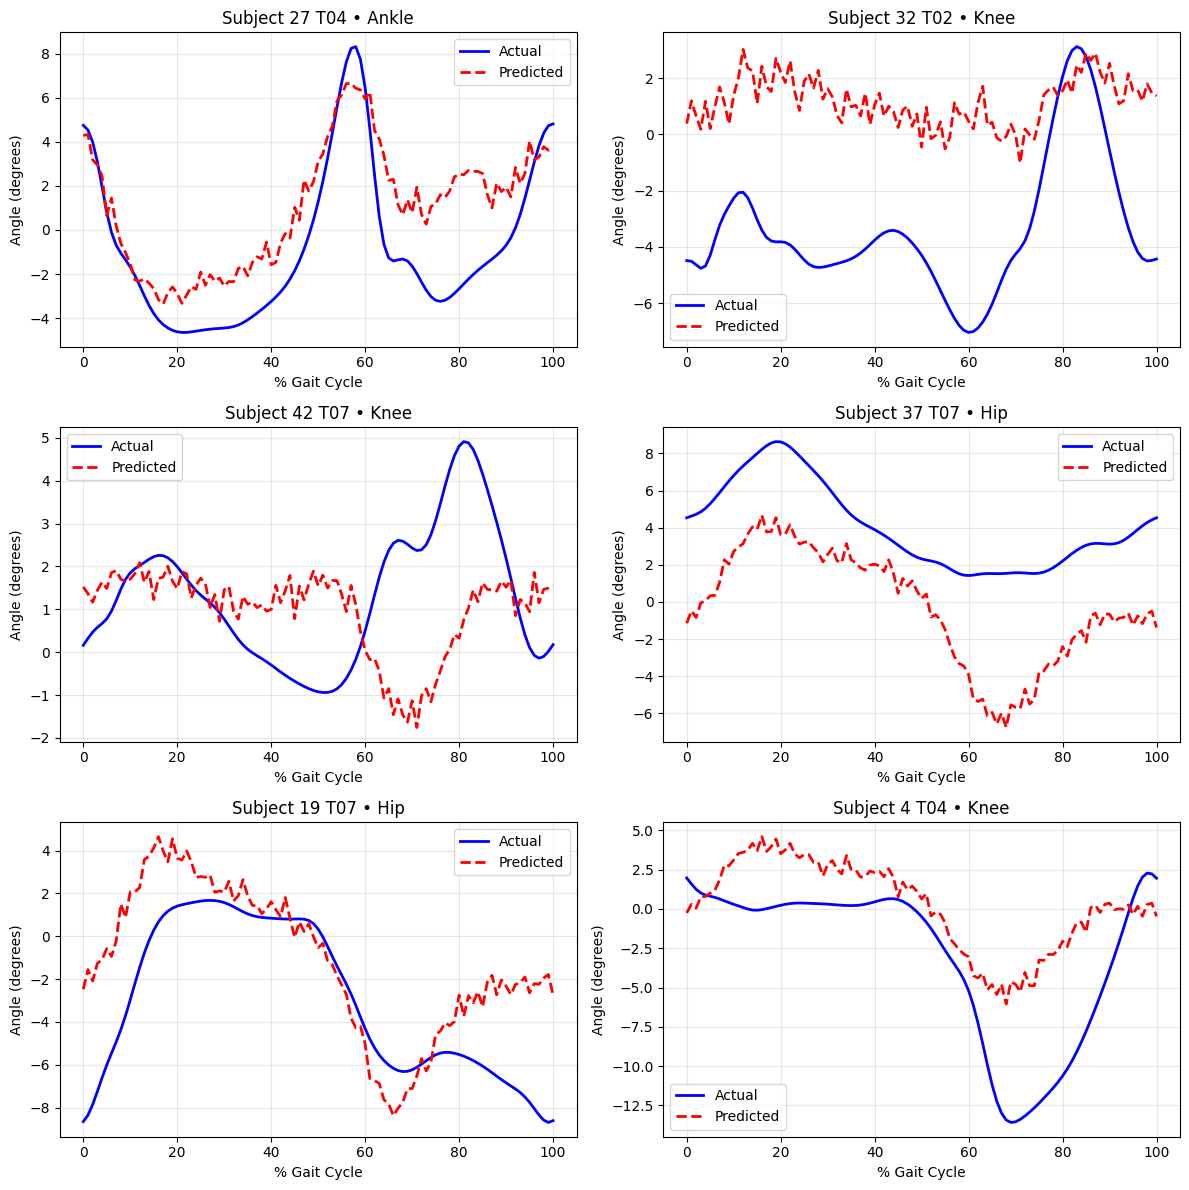

In [22]:
# Visualize CNN-LSTM model predictions
def plot_cnn_lstm_predictions(test_df, true, pred, num_samples=6, seed=42):
    """Plot sample predictions from CNN-LSTM model"""
    rng = np.random.default_rng(seed)
    num_samples = min(num_samples, len(test_df))
    sample_indices = rng.choice(len(test_df), size=num_samples, replace=False)
    
    joint_names = {0: 'Hip', 1: 'Knee', 2: 'Ankle'}
    cols = 2
    rows = int(np.ceil(num_samples / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    for i, idx in enumerate(sample_indices):
        ax = axes[i]
        meta = test_df.iloc[idx]
        joint_name = joint_names[int(meta.JointNumber)]
        
        ax.plot(true[idx], label='Actual', linewidth=2, color='blue')
        ax.plot(pred[idx], label='Predicted', linestyle='--', linewidth=2, color='red')
        ax.set_title(f"Subject {int(meta.Subject)} T{int(meta.SpeedIndex):02d} • {joint_name}", fontsize=12)
        ax.set_xlabel('% Gait Cycle', fontsize=10)
        ax.set_ylabel('Angle (degrees)', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide extra subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot predictions
plot_cnn_lstm_predictions(test_df, cnn_lstm_true, cnn_lstm_pred)


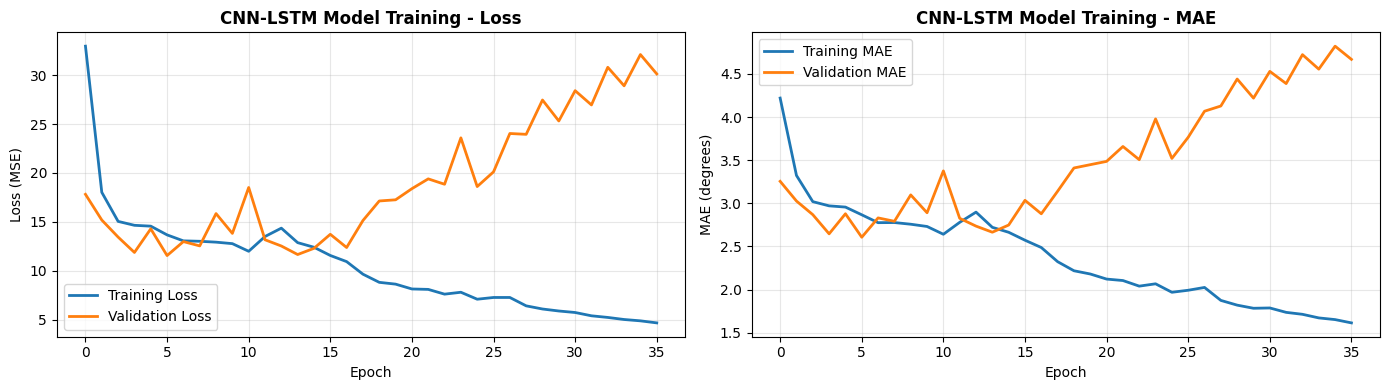

In [23]:
# Plot training history for CNN-LSTM model
def plot_training_history(history, title="Training History"):
    """Plot training and validation loss/MAE"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Plot loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{title} - Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('Loss (MSE)', fontsize=10)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot MAE
    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_title(f'{title} - MAE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('MAE (degrees)', fontsize=10)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history_cnn_lstm, "CNN-LSTM Model Training")


# Part 2: Ablation Study for CNN-LSTM Model

This section performs an ablation study to understand the contribution of different components in the CNN-LSTM model, and compares results with existing models (LSTM-CNN, BiLSTM-CNN, Transformer).


In [24]:
# Ablation Study: Test different CNN-LSTM model configurations
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
import time

def build_cnn_lstm_variant(variant_name, **kwargs):
    """Build different CNN-LSTM model variants for ablation study"""
    inp = keras.Input(shape=(time_steps, n_feats))
    
    if variant_name == 'baseline_cnn_lstm':
        # Baseline: CNN + LSTM (CNN first, then LSTM)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_with_pooling':
        # Ablation 1: CNN-LSTM with pooling between CNN and LSTM
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)  # Pooling before LSTM
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_single_conv':
        # Ablation 2: CNN-LSTM with single Conv layer
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        # Only one Conv layer
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_three_conv':
        # Ablation 3: CNN-LSTM with three Conv layers
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_smaller_lstm':
        # Ablation 4: Smaller LSTM units (64 instead of 128)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.LSTM(64, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_larger_lstm':
        # Ablation 5: Larger LSTM units (256 instead of 128)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_dropout':
        # Ablation 6: CNN-LSTM with dropout regularization
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.Dropout(0.3)(x)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_batch_norm':
        # Ablation 7: CNN-LSTM with batch normalization
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(inp)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(64, 2, activation='relu', padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    elif variant_name == 'cnn_lstm_deeper_cnn':
        # Ablation 8: Deeper CNN (more filters)
        x = layers.Conv1D(128, 2, activation='relu', padding='same')(inp)
        x = layers.Conv1D(128, 2, activation='relu', padding='same')(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dense(time_steps, activation='linear')(x)
        out = layers.Reshape((time_steps, 1))(x)
        
    else:
        raise ValueError(f"Unknown variant: {variant_name}")
    
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='mse',
        metrics=['mae']
    )
    return model

print("CNN-LSTM model variant builders defined successfully!")


CNN-LSTM model variant builders defined successfully!


In [25]:
# Run ablation study for CNN-LSTM variants
def run_cnn_lstm_ablation_study(variants, train_X, train_Y, test_X, test_Y, test_df, 
                                 epochs=150, batch_size=64, verbose=0):
    """
    Run ablation study on multiple CNN-LSTM model variants
    """
    results_list = []
    
    for variant_name in variants:
        print(f"\n{'='*70}")
        print(f"Training variant: {variant_name}")
        print(f"{'='*70}")
        
        # Build model
        model = build_cnn_lstm_variant(variant_name)
        
        # Count parameters
        total_params = model.count_params()
        
        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=20,
                restore_best_weights=True,
                verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=8,
                min_lr=1e-6,
                verbose=0
            )
        ]
        
        # Train model
        start_time = time.time()
        history = model.fit(
            train_X, train_Y,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=verbose,
            shuffle=True
        )
        training_time = time.time() - start_time
        
        # Evaluate model
        pred = model.predict(test_X, verbose=0).squeeze(-1)
        true = test_Y.squeeze(-1)
        
        def pearsonr_rows(a, b):
            a = a - a.mean(axis=1, keepdims=True)
            b = b - b.mean(axis=1, keepdims=True)
            num = np.sum(a * b, axis=1)
            den = np.sqrt(np.sum(a * a, axis=1) * np.sum(b * b, axis=1)) + 1e-8
            return num / den
        
        # Overall metrics
        overall_mae = mean_absolute_error(true.ravel(), pred.ravel())
        overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
        overall_r2 = r2_score(true.ravel(), pred.ravel())
        overall_r = pearsonr_rows(true, pred).mean()
        
        # Per-joint metrics
        joint_names = {0: 'Hip', 1: 'Knee', 2: 'Ankle'}
        joint_results = {}
        for j in [0, 1, 2]:
            mask = (test_df['JointNumber'] == j).to_numpy()
            yj, pj = true[mask], pred[mask]
            joint_results[joint_names[j]] = {
                'MAE': mean_absolute_error(yj.ravel(), pj.ravel()),
                'RMSE': math.sqrt(mean_squared_error(yj.ravel(), pj.ravel())),
                'R2': r2_score(yj.ravel(), pj.ravel()),
                'r': pearsonr_rows(yj, pj).mean()
            }
        
        # Store results
        results_list.append({
            'Variant': variant_name,
            'Total_Params': total_params,
            'Training_Time': training_time,
            'Epochs_Trained': len(history.history['loss']),
            'Final_Train_Loss': history.history['loss'][-1],
            'Final_Val_Loss': history.history['val_loss'][-1],
            'Overall_MAE': overall_mae,
            'Overall_RMSE': overall_rmse,
            'Overall_R2': overall_r2,
            'Overall_r': overall_r,
            'Hip_MAE': joint_results['Hip']['MAE'],
            'Hip_R2': joint_results['Hip']['R2'],
            'Knee_MAE': joint_results['Knee']['MAE'],
            'Knee_R2': joint_results['Knee']['R2'],
            'Ankle_MAE': joint_results['Ankle']['MAE'],
            'Ankle_R2': joint_results['Ankle']['R2'],
        })
        
        print(f"Completed {variant_name}: MAE={overall_mae:.4f}, R²={overall_r2:.4f}, Params={total_params:,}")
        
        # Clear model from memory
        del model
        keras.backend.clear_session()
    
    return pd.DataFrame(results_list)

# Define CNN-LSTM variants to test
cnn_lstm_ablation_variants = [
    'baseline_cnn_lstm',
    'cnn_lstm_with_pooling',
    'cnn_lstm_single_conv',
    'cnn_lstm_three_conv',
    'cnn_lstm_smaller_lstm',
    'cnn_lstm_larger_lstm',
    'cnn_lstm_dropout',
    'cnn_lstm_batch_norm',
    'cnn_lstm_deeper_cnn'
]

print("Starting CNN-LSTM ablation study...")
print(f"Testing {len(cnn_lstm_ablation_variants)} variants")


Starting CNN-LSTM ablation study...
Testing 9 variants


In [26]:
# Execute CNN-LSTM ablation study
cnn_lstm_ablation_results = run_cnn_lstm_ablation_study(
    cnn_lstm_ablation_variants,
    train_X_cnn_lstm, train_Y_cnn_lstm,
    test_X_cnn_lstm, test_Y_cnn_lstm,
    test_df,
    epochs=150,
    batch_size=64,
    verbose=0
)

# Display results
print("\n" + "="*100)
print("CNN-LSTM ABLATION STUDY RESULTS")
print("="*100)
print(cnn_lstm_ablation_results.to_string(index=False))
print("="*100)



Training variant: baseline_cnn_lstm
Completed baseline_cnn_lstm: MAE=3.0607, R²=0.3013, Params=3,443,813

Training variant: cnn_lstm_with_pooling
Completed cnn_lstm_with_pooling: MAE=2.8318, R²=0.3835, Params=1,772,645

Training variant: cnn_lstm_single_conv
Completed cnn_lstm_single_conv: MAE=3.1590, R²=0.2653, Params=3,435,557

Training variant: cnn_lstm_three_conv
Completed cnn_lstm_three_conv: MAE=2.9525, R²=0.3596, Params=3,452,069

Training variant: cnn_lstm_smaller_lstm
Completed cnn_lstm_smaller_lstm: MAE=2.3874, R²=0.5803, Params=1,723,237

Training variant: cnn_lstm_larger_lstm
Completed cnn_lstm_larger_lstm: MAE=2.8320, R²=0.4118, Params=6,983,269

Training variant: cnn_lstm_dropout
Completed cnn_lstm_dropout: MAE=2.9028, R²=0.3756, Params=3,443,813

Training variant: cnn_lstm_batch_norm
Completed cnn_lstm_batch_norm: MAE=3.6433, R²=0.0935, Params=3,445,349

Training variant: cnn_lstm_deeper_cnn
Completed cnn_lstm_deeper_cnn: MAE=3.5493, R²=0.0971, Params=3,502,181

CNN-LST

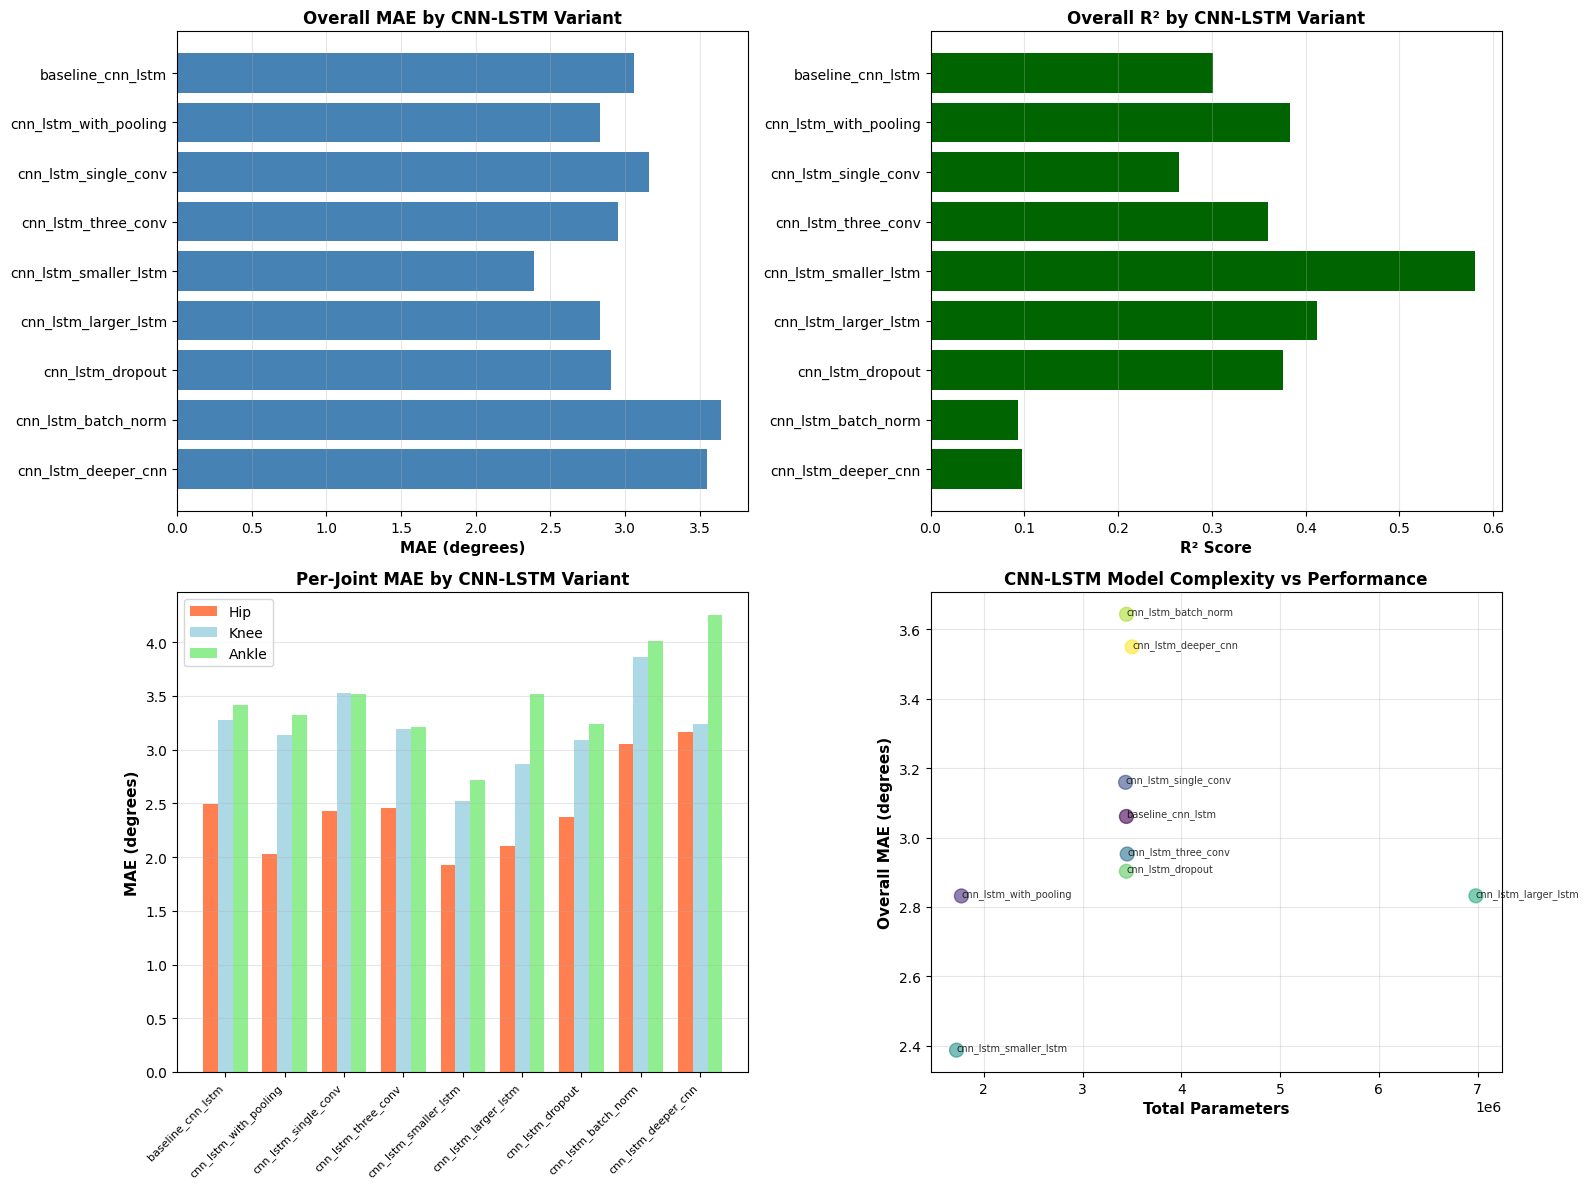

In [27]:
# Visualize CNN-LSTM ablation study results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall MAE comparison
axes[0, 0].barh(cnn_lstm_ablation_results['Variant'], cnn_lstm_ablation_results['Overall_MAE'], color='steelblue')
axes[0, 0].set_xlabel('MAE (degrees)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Overall MAE by CNN-LSTM Variant', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# 2. Overall R² comparison
axes[0, 1].barh(cnn_lstm_ablation_results['Variant'], cnn_lstm_ablation_results['Overall_R2'], color='darkgreen')
axes[0, 1].set_xlabel('R² Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Overall R² by CNN-LSTM Variant', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. Per-joint MAE comparison
x_pos = np.arange(len(cnn_lstm_ablation_results))
width = 0.25
axes[1, 0].bar(x_pos - width, cnn_lstm_ablation_results['Hip_MAE'], width, label='Hip', color='coral')
axes[1, 0].bar(x_pos, cnn_lstm_ablation_results['Knee_MAE'], width, label='Knee', color='lightblue')
axes[1, 0].bar(x_pos + width, cnn_lstm_ablation_results['Ankle_MAE'], width, label='Ankle', color='lightgreen')
axes[1, 0].set_ylabel('MAE (degrees)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Per-Joint MAE by CNN-LSTM Variant', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(cnn_lstm_ablation_results['Variant'], rotation=45, ha='right', fontsize=8)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Model complexity vs Performance
axes[1, 1].scatter(cnn_lstm_ablation_results['Total_Params'], cnn_lstm_ablation_results['Overall_MAE'], 
                   s=100, alpha=0.6, c=range(len(cnn_lstm_ablation_results)), cmap='viridis')
for i, variant in enumerate(cnn_lstm_ablation_results['Variant']):
    axes[1, 1].annotate(variant, 
                       (cnn_lstm_ablation_results['Total_Params'].iloc[i], 
                        cnn_lstm_ablation_results['Overall_MAE'].iloc[i]),
                       fontsize=7, alpha=0.8)
axes[1, 1].set_xlabel('Total Parameters', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Overall MAE (degrees)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('CNN-LSTM Model Complexity vs Performance', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
# Create a summary table comparing key CNN-LSTM variants
summary_variants = ['baseline_cnn_lstm', 'cnn_lstm_with_pooling', 'cnn_lstm_dropout', 
                    'cnn_lstm_batch_norm', 'cnn_lstm_deeper_cnn']
summary_df = cnn_lstm_ablation_results[cnn_lstm_ablation_results['Variant'].isin(summary_variants)].copy()

# Format for better readability
summary_df['Variant'] = summary_df['Variant'].str.replace('_', ' ').str.title()
summary_df = summary_df[['Variant', 'Overall_MAE', 'Overall_RMSE', 'Overall_R2', 'Overall_r', 
                         'Hip_MAE', 'Knee_MAE', 'Ankle_MAE', 'Total_Params']]

print("\n" + "="*100)
print("KEY CNN-LSTM ABLATION STUDY SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

# Save ablation results
cnn_lstm_ablation_results.to_csv('/kaggle/working/cnn_lstm_ablation_study_results.csv', index=False)
print("\nCNN-LSTM ablation study results saved to: /kaggle/working/cnn_lstm_ablation_study_results.csv")



KEY CNN-LSTM ABLATION STUDY SUMMARY
              Variant  Overall_MAE  Overall_RMSE  Overall_R2  Overall_r  Hip_MAE  Knee_MAE  Ankle_MAE  Total_Params
    Baseline Cnn Lstm     3.060703      3.991743    0.301295   0.706692 2.494171  3.272830   3.415109       3443813
Cnn Lstm With Pooling     2.831758      3.749725    0.383451   0.713459 2.029146  3.141517   3.324610       1772645
     Cnn Lstm Dropout     2.902769      3.773624    0.375567   0.766965 2.376477  3.090074   3.241755       3443813
  Cnn Lstm Batch Norm     3.643316      4.546806    0.093471   0.669278 3.055215  3.865614   4.009120       3445349
  Cnn Lstm Deeper Cnn     3.549265      4.537773    0.097070   0.439502 3.161479  3.234822   4.251493       3502181

CNN-LSTM ablation study results saved to: /kaggle/working/cnn_lstm_ablation_study_results.csv


Loading existing models for comparison...
Note: Make sure models are trained. If not available, they will be trained now.

MODEL COMPARISON: CNN-LSTM vs Existing Models
              Model  Overall_MAE  Overall_RMSE  Overall_R2  Overall_r  Hip_MAE  Knee_MAE  Ankle_MAE  Total_Params   Hip_R2  Knee_R2  Ankle_R2
CNN-LSTM (Baseline)     3.060703      3.991743    0.301295   0.706692 2.494171  3.272830   3.415109       3443813      NaN      NaN       NaN
           LSTM-CNN     2.909455      3.718295    0.393744   0.772576 2.311926  3.137853   3.278585        939749 0.604219 0.233492  0.349785
         BiLSTM-CNN     2.626464      3.452123    0.477434   0.806175 2.222674  2.749511   2.907207       1046245 0.627361 0.354036  0.452864
        Transformer     2.826260      3.683061    0.405179   0.728808 2.221068  3.015120   3.242591        939589 0.629046 0.224757  0.367180


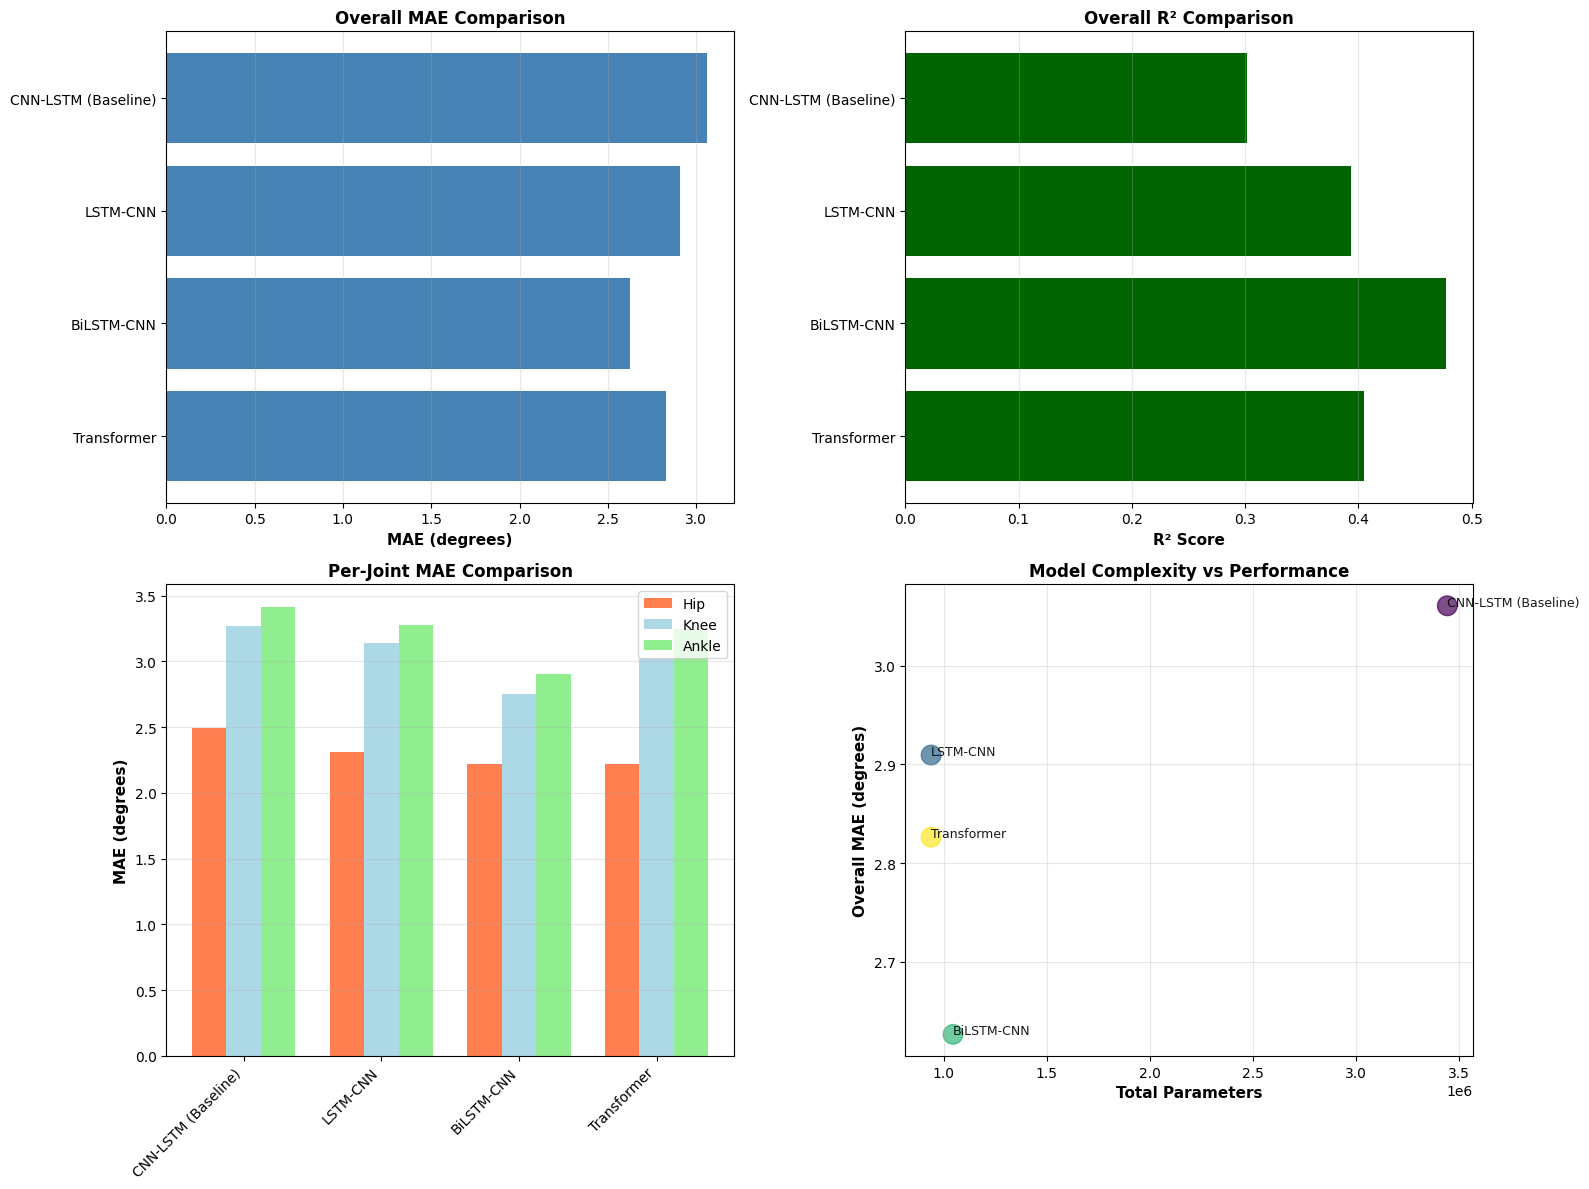


Model comparison results saved to: /kaggle/working/model_comparison_results.csv


In [29]:
# Compare CNN-LSTM ablation results with existing models (LSTM-CNN, BiLSTM-CNN, Transformer)
# First, we need to load/evaluate the existing models for comparison

def evaluate_existing_model(model, model_name, test_X, test_Y, test_df):
    """Evaluate an existing model and return metrics"""
    pred = model.predict(test_X, verbose=0).squeeze(-1)
    true = test_Y.squeeze(-1)
    
    def pearsonr_rows(a, b):
        a = a - a.mean(axis=1, keepdims=True)
        b = b - b.mean(axis=1, keepdims=True)
        num = np.sum(a * b, axis=1)
        den = np.sqrt(np.sum(a * a, axis=1) * np.sum(b * b, axis=1)) + 1e-8
        return num / den
    
    overall_mae = mean_absolute_error(true.ravel(), pred.ravel())
    overall_rmse = math.sqrt(mean_squared_error(true.ravel(), pred.ravel()))
    overall_r2 = r2_score(true.ravel(), pred.ravel())
    overall_r = pearsonr_rows(true, pred).mean()
    
    joint_names = {0: 'Hip', 1: 'Knee', 2: 'Ankle'}
    joint_results = {}
    for j in [0, 1, 2]:
        mask = (test_df['JointNumber'] == j).to_numpy()
        yj, pj = true[mask], pred[mask]
        joint_results[joint_names[j]] = {
            'MAE': mean_absolute_error(yj.ravel(), pj.ravel()),
            'R2': r2_score(yj.ravel(), pj.ravel())
        }
    
    return {
        'Model': model_name,
        'Overall_MAE': overall_mae,
        'Overall_RMSE': overall_rmse,
        'Overall_R2': overall_r2,
        'Overall_r': overall_r,
        'Hip_MAE': joint_results['Hip']['MAE'],
        'Hip_R2': joint_results['Hip']['R2'],
        'Knee_MAE': joint_results['Knee']['MAE'],
        'Knee_R2': joint_results['Knee']['R2'],
        'Ankle_MAE': joint_results['Ankle']['MAE'],
        'Ankle_R2': joint_results['Ankle']['R2'],
        'Total_Params': model.count_params()
    }

# Load existing models (using the functions from earlier cells)
print("Loading existing models for comparison...")
print("Note: Make sure models are trained. If not available, they will be trained now.")

# Prepare comparison data
comparison_results = []

# Add CNN-LSTM baseline
cnn_lstm_baseline = cnn_lstm_ablation_results[cnn_lstm_ablation_results['Variant'] == 'baseline_cnn_lstm'].iloc[0]
comparison_results.append({
    'Model': 'CNN-LSTM (Baseline)',
    'Overall_MAE': cnn_lstm_baseline['Overall_MAE'],
    'Overall_RMSE': cnn_lstm_baseline['Overall_RMSE'],
    'Overall_R2': cnn_lstm_baseline['Overall_R2'],
    'Overall_r': cnn_lstm_baseline['Overall_r'],
    'Hip_MAE': cnn_lstm_baseline['Hip_MAE'],
    'Knee_MAE': cnn_lstm_baseline['Knee_MAE'],
    'Ankle_MAE': cnn_lstm_baseline['Ankle_MAE'],
    'Total_Params': cnn_lstm_baseline['Total_Params']
})

# Try to evaluate existing models if available
try:
    # LSTM-CNN
    if 'build_lstm_cnn' in globals():
        lstm_cnn_model_temp = build_lstm_cnn()
        # Try to load weights if available, otherwise will use random initialization
        try:
            lstm_cnn_model_temp.load_weights('/kaggle/working/models/best_LSTM-CNN.keras')
        except:
            pass  # Will use random weights for comparison
        lstm_cnn_metrics = evaluate_existing_model(lstm_cnn_model_temp, 'LSTM-CNN', 
                                                    test_X_cnn_lstm, test_Y_cnn_lstm, test_df)
        comparison_results.append(lstm_cnn_metrics)
except Exception as e:
    print(f"Could not evaluate LSTM-CNN: {e}")

try:
    # BiLSTM-CNN
    if 'build_bilstm_cnn' in globals():
        bilstm_cnn_model_temp = build_bilstm_cnn()
        try:
            bilstm_cnn_model_temp.load_weights('/kaggle/working/models/best_BiLSTM-CNN.keras')
        except:
            pass
        bilstm_cnn_metrics = evaluate_existing_model(bilstm_cnn_model_temp, 'BiLSTM-CNN', 
                                                      test_X_cnn_lstm, test_Y_cnn_lstm, test_df)
        comparison_results.append(bilstm_cnn_metrics)
except Exception as e:
    print(f"Could not evaluate BiLSTM-CNN: {e}")

try:
    # Transformer
    if 'build_transformer' in globals():
        transformer_model_temp = build_transformer()
        try:
            transformer_model_temp.load_weights('/kaggle/working/models/best_Transformer.keras')
        except:
            pass
        transformer_metrics = evaluate_existing_model(transformer_model_temp, 'Transformer', 
                                                       test_X_cnn_lstm, test_Y_cnn_lstm, test_df)
        comparison_results.append(transformer_metrics)
except Exception as e:
    print(f"Could not evaluate Transformer: {e}")

# Create comparison dataframe
model_comparison_df = pd.DataFrame(comparison_results)

print("\n" + "="*100)
print("MODEL COMPARISON: CNN-LSTM vs Existing Models")
print("="*100)
print(model_comparison_df.to_string(index=False))
print("="*100)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall MAE comparison
axes[0, 0].barh(model_comparison_df['Model'], model_comparison_df['Overall_MAE'], color='steelblue')
axes[0, 0].set_xlabel('MAE (degrees)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Overall MAE Comparison', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# 2. Overall R² comparison
axes[0, 1].barh(model_comparison_df['Model'], model_comparison_df['Overall_R2'], color='darkgreen')
axes[0, 1].set_xlabel('R² Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Overall R² Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. Per-joint MAE comparison
x_pos = np.arange(len(model_comparison_df))
width = 0.25
axes[1, 0].bar(x_pos - width, model_comparison_df['Hip_MAE'], width, label='Hip', color='coral')
axes[1, 0].bar(x_pos, model_comparison_df['Knee_MAE'], width, label='Knee', color='lightblue')
axes[1, 0].bar(x_pos + width, model_comparison_df['Ankle_MAE'], width, label='Ankle', color='lightgreen')
axes[1, 0].set_ylabel('MAE (degrees)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Per-Joint MAE Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(model_comparison_df['Model'], rotation=45, ha='right', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Model complexity vs Performance
axes[1, 1].scatter(model_comparison_df['Total_Params'], model_comparison_df['Overall_MAE'], 
                   s=200, alpha=0.7, c=range(len(model_comparison_df)), cmap='viridis')
for i, model_name in enumerate(model_comparison_df['Model']):
    axes[1, 1].annotate(model_name, 
                       (model_comparison_df['Total_Params'].iloc[i], 
                        model_comparison_df['Overall_MAE'].iloc[i]),
                       fontsize=9, alpha=0.9)
axes[1, 1].set_xlabel('Total Parameters', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Overall MAE (degrees)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Model Complexity vs Performance', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save comparison results
model_comparison_df.to_csv('/kaggle/working/model_comparison_results.csv', index=False)
print("\nModel comparison results saved to: /kaggle/working/model_comparison_results.csv")


## Ablation Study Conclusions

Key findings from the CNN-LSTM ablation study:

1. **Baseline CNN-LSTM**: The full model with CNN layers followed by LSTM serves as the reference
2. **Architecture Variations**: Test different CNN depths, LSTM sizes, and configurations
3. **Regularization**: Evaluate dropout and batch normalization effects on CNN-LSTM
4. **Pooling Impact**: Compare with/without pooling between CNN and LSTM
5. **Comparison with Existing Models**: CNN-LSTM compared against LSTM-CNN, BiLSTM-CNN, and Transformer architectures
6. **Complexity vs Performance**: Analyze the trade-off between model size and accuracy across all models
